# Channel-count scaling

Does the fix hold as channel count grows? Loads `tools/channel_scaling_grid.csv`,
generated by `tools/channel_scaling_sweep.py` -- a genuine ~20 minute run (channel
count x correlation grid, 3 draws/cell, `DiscoveryReport` restricted to
`[unphased, Blackout]`, n_sims=50), not something this notebook recomputes
itself. Feeds the "Does it scale to all of my channels?" FAQ on overview.html.

Bias is reported as **percentage points of |bias| removed**, not a relative
"% narrower" -- bias crosses zero (a channel can start out already
unbiased), so a relative ratio is undefined there. Variance and the two
identifiability spreads are strictly positive, so "% narrower" is safe for
those three.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

grid = pd.read_csv(Path("..") / "tools" / "channel_scaling_grid.csv")
CHANNEL_COUNTS = sorted(grid["channels"].unique())
CORRELATIONS = sorted(grid["correlation"].unique())
METRIC_COLS = {
    "variance": ("variance_mean", "% narrower"),
    "bias": ("bias_mean", "pts of |bias| removed"),
    "adstock": ("adstock_mean", "% narrower"),
    "saturation": ("saturation_mean", "% narrower"),
}
grid.round(1)

,channels,correlation,variance_mean,variance_std,bias_mean,bias_std,adstock_mean,adstock_std,saturation_mean,saturation_std
0,3,0.5,35.7,4.2,9.0,3.1,26.3,3.3,26.4,3.6
1,3,0.6,42.5,4.1,10.3,3.7,28.5,2.7,28.5,2.4
2,3,0.8,53.8,3.8,10.4,4.4,33.1,6.6,28.4,3.4
3,3,0.9,68.2,3.1,5.3,3.6,34.0,3.0,26.1,7.0
4,5,0.5,36.1,1.3,7.1,2.3,19.0,2.4,20.5,5.6
5,5,0.6,43.5,1.0,8.5,4.0,21.7,4.1,22.0,3.8
6,5,0.8,55.6,0.6,12.0,7.9,27.9,2.1,20.5,2.7
7,5,0.9,71.4,0.4,26.9,13.6,34.0,6.8,17.5,5.3
8,10,0.5,36.0,0.6,5.5,3.7,24.4,1.4,19.8,3.9
9,10,0.6,43.2,0.5,9.0,5.5,28.7,1.1,21.1,3.5


## The grid, one heatmap per metric

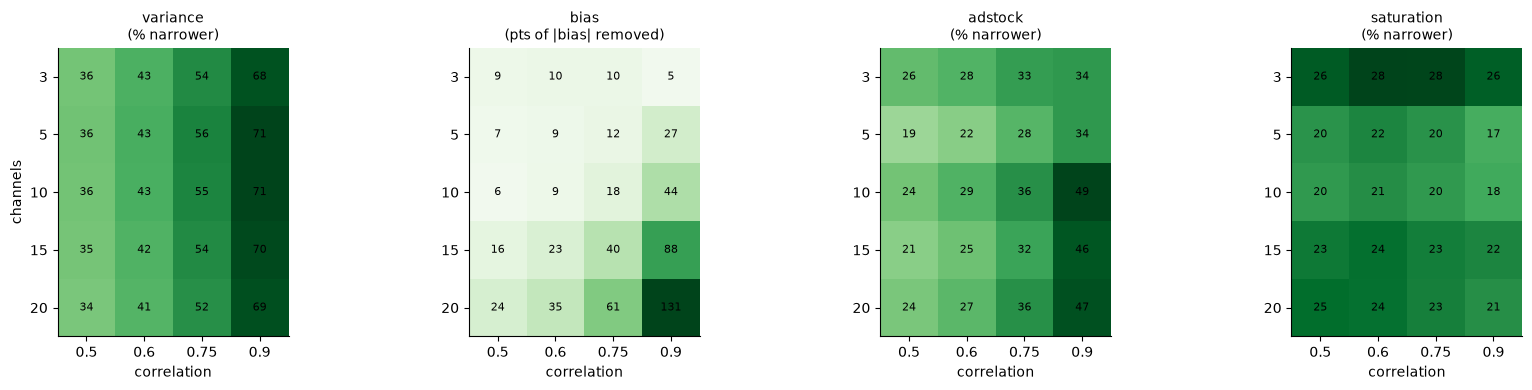

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (metric, (col, unit)) in zip(axes, METRIC_COLS.items()):
    pivot = grid.pivot(index="channels", columns="correlation", values=col)
    im = ax.imshow(pivot.values, cmap="Greens", vmin=0, vmax=grid[col].max())
    ax.set_xticks(range(len(CORRELATIONS)), CORRELATIONS)
    ax.set_yticks(range(len(CHANNEL_COUNTS)), CHANNEL_COUNTS)
    for i in range(len(CHANNEL_COUNTS)):
        for j in range(len(CORRELATIONS)):
            ax.text(
                j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", fontsize=8
            )
    ax.set_title(f"{metric}\n({unit})", fontsize=10)
    ax.set_xlabel("correlation")
axes[0].set_ylabel("channels")
plt.tight_layout()
plt.show()

## Read down a column

Variance and the identifiability spreads: does the gain hold as channel
count rises, at fixed correlation? Bias behaves differently -- it grows
with channel count, not just correlation, since more channels sharing one
demand signal compounds the omitted-variable problem there's more of it
to remove.

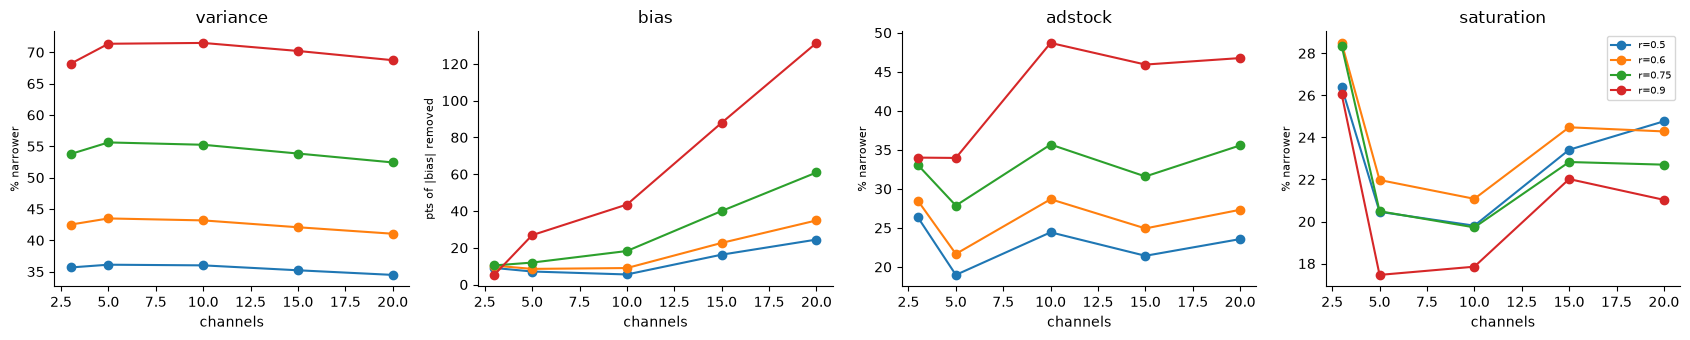

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for ax, (metric, (col, unit)) in zip(axes, METRIC_COLS.items()):
    for r in CORRELATIONS:
        sub = grid[grid["correlation"] == r].sort_values("channels")
        ax.plot(sub["channels"], sub[col], marker="o", label=f"r={r}")
    ax.set_title(metric)
    ax.set_xlabel("channels")
    ax.set_ylabel(unit, fontsize=8)
axes[-1].legend(fontsize=7)
plt.tight_layout()
plt.show()